In [1]:
import sys
sys.path.append("/Users/chris/Documents/higs-vision")
import torch
import json

from src.data import load_config, load_processed
from src.models import HiggsDNN
from src.train import train, save_training_run

config = load_config("/Users/chris/Documents/higs-vision/config.yaml")
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed(config)

Loaded processed data from /Users/chris/Documents/higs-vision/data/processed/
  Train: (700000, 28), Val: (150000, 28), Test: (150000, 28)


In [2]:
# Load best params
with open("/Users/chris/Documents/higs-vision/results/optuna/best_params.json") as f:
    best = json.load(f)

width = best["hidden_width"]
model = HiggsDNN(
    input_dim=config["dataset"]["n_features"],
    hidden_dims=[width, width // 2, width // 4, width // 8],
    activation=best["activation"],
    dropout_rate=best["dropout"],
    use_batch_norm=best["batch_norm"]
)

print(f"Model created: width={width}, activation={best['activation']}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created: width=1024, activation=GELU
Parameters: 718,849


In [3]:
import copy
final_config = copy.deepcopy(config)
final_config["dnn"]["learning_rate"] = best["learning_rate"]
final_config["dnn"]["weight_decay"] = best["weight_decay"]
final_config["dnn"]["batch_size"] = best["batch_size"]
final_config["dnn"]["cosine_annealing"] = best["cosine_annealing"]
final_config["dnn"]["max_epochs"] = 60
final_config["dnn"]["early_stopping_patience"] = 10

model, history = train(
    model, X_train, y_train, X_val, y_val,
    final_config, seed=config["seeds"]["dnn_final"]
)

Epoch   1 | Train Loss: 0.5803 | Val Loss: 0.5378 | Val AUC: 0.8027 | Time: 31.4s
Epoch   2 | Train Loss: 0.5415 | Val Loss: 0.5184 | Val AUC: 0.8179 | Time: 28.6s
Epoch   3 | Train Loss: 0.5297 | Val Loss: 0.5116 | Val AUC: 0.8243 | Time: 28.6s
Epoch   4 | Train Loss: 0.5228 | Val Loss: 0.5058 | Val AUC: 0.8283 | Time: 29.5s
Epoch   5 | Train Loss: 0.5190 | Val Loss: 0.5028 | Val AUC: 0.8319 | Time: 28.0s
Epoch   6 | Train Loss: 0.5148 | Val Loss: 0.4996 | Val AUC: 0.8334 | Time: 28.7s
Epoch   7 | Train Loss: 0.5126 | Val Loss: 0.4991 | Val AUC: 0.8347 | Time: 29.4s
Epoch   8 | Train Loss: 0.5110 | Val Loss: 0.4950 | Val AUC: 0.8368 | Time: 28.9s
Epoch   9 | Train Loss: 0.5085 | Val Loss: 0.4943 | Val AUC: 0.8377 | Time: 28.8s
Epoch  10 | Train Loss: 0.5065 | Val Loss: 0.4935 | Val AUC: 0.8391 | Time: 28.7s
Epoch  11 | Train Loss: 0.5049 | Val Loss: 0.4922 | Val AUC: 0.8394 | Time: 29.0s
Epoch  12 | Train Loss: 0.5037 | Val Loss: 0.4919 | Val AUC: 0.8400 | Time: 28.7s
Epoch  13 | Trai

In [4]:
save_training_run(model, history, final_config, "models/dnn/final_optuna", seed=config["seeds"]["dnn_final"])

Saved model and run info to models/dnn/final_optuna/


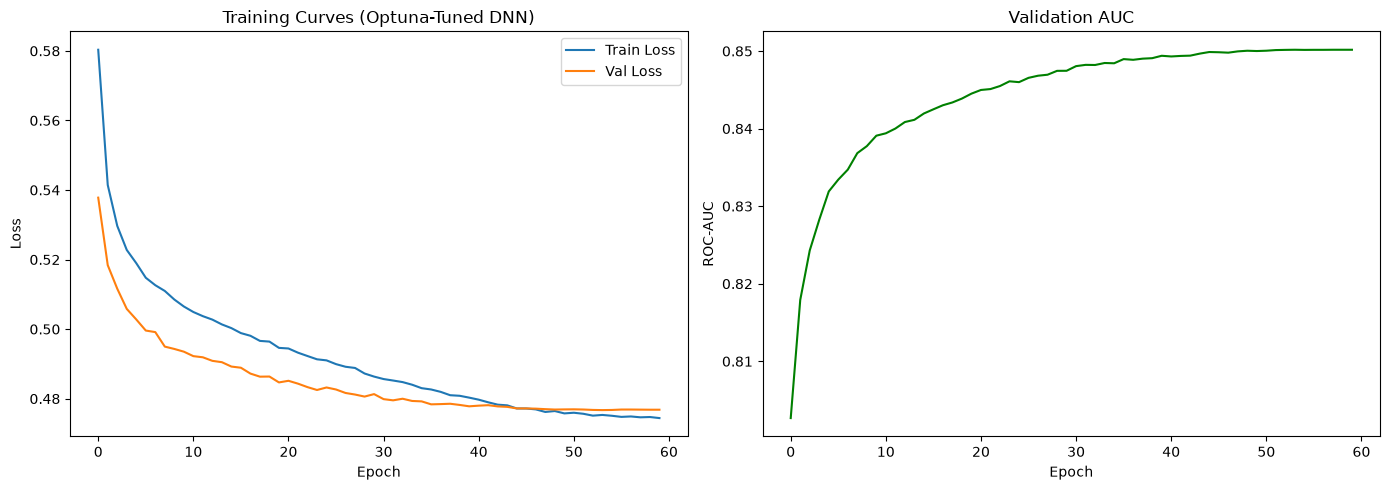

Best validation AUC: 0.8502
Total time: 28.9 min


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Curves (Optuna-Tuned DNN)")
axes[0].legend()

axes[1].plot(history["val_auc"], label="Val AUC", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Validation AUC")

plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/final_dnn_training.png", dpi=150)
plt.show()

print(f"Best validation AUC: {max(history['val_auc']):.4f}")
print(f"Total time: {history['total_time']/60:.1f} min")